<a href="https://colab.research.google.com/github/Sneha17A/Learning_ML/blob/main/Predicting%20Heart%20Disease%20-%20Binary%20classification%20-%20Tabular%20Data.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Introduction

This colab shows how to set up and train a Neural Network model for *binary classification*, when the dataset is *tabular* (rather than unstructured data like images or text) and has a mix of numeric and categorical features. Since tabular datasets are often made available in CSV files, the colab demonstrates the full CSV-to-trained-model workflow.




### The dataset

The dataset ([more background on the data](https://archive.ics.uci.edu/ml/datasets/heart+Disease)) has information on 303 patients, one in each row. Each column (i.e., feature) contains information on a particular attribute of the patient. The column named "Target" indicates if the patient has been diagnosed with heart disease or not and is the label (i.e., the dependent variable) that we want to predict using the other columns.

Feature description (copied from [here](https://keras.io/examples/structured_data/structured_data_classification_from_scratch/)):

Column| Description| Feature Type
------------|--------------------|----------------------
Age | Age in years | Numerical
Sex | (1 = male; 0 = female) | Categorical
CP | Chest pain type (0, 1, 2, 3, 4) | Categorical
Trestbpd | Resting blood pressure (in mm Hg on admission) | Numerical
Chol | Serum cholesterol in mg/dl | Numerical
FBS | fasting blood sugar in 120 mg/dl (1 = true; 0 = false) | Categorical
RestECG | Resting electrocardiogram results (0, 1, 2) | Categorical
Thalach | Maximum heart rate achieved | Numerical
Exang | Exercise induced angina (1 = yes; 0 = no) | Categorical
Oldpeak | ST depression induced by exercise relative to rest | Numerical
Slope | Slope of the peak exercise ST segment | Numerical
CA | Number of major vessels (0-3) colored by fluoroscopy | Both numerical & categorical
Thal | 3 = normal; 6 = fixed defect; 7 = reversible defect | Categorical
Target | Diagnosis of heart disease (1 = true; 0 = false) | Target



# Technical preliminaries

In [7]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [8]:
keras.utils.set_random_seed(42)

# Read in the data

The dataset has 303 rows and 14 columns (13 independent variables + 1 dependent variable):

In [9]:
df = pd.read_csv("http://storage.googleapis.com/download.tensorflow.org/data/heart.csv")

In [10]:
df.shape

(303, 14)

In [11]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,1,145,233,1,2,150,0,2.3,3,0,fixed,0
1,67,1,4,160,286,0,2,108,1,1.5,2,3,normal,1
2,67,1,4,120,229,0,2,129,1,2.6,2,2,reversible,0
3,37,1,3,130,250,0,0,187,0,3.5,3,0,normal,0
4,41,0,2,130,204,0,2,172,0,1.4,1,0,normal,0


In [12]:
df.target.value_counts(normalize= True, dropna = False)

,proportion
target,
0,0.726073
1,0.273927


# Preprocessing

In [13]:
categorical_varibles = ['sex','cp','fbs','restecg','exang','ca','thal']
numerics = ['age','trestbps','chol','thalach','oldpeak','slope']

In [14]:
df = pd.get_dummies(df,columns= categorical_varibles)

In [15]:
df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,63,145,233,150,2.3,3,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,67,160,286,108,1.5,2,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,67,120,229,129,2.6,2,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,37,130,250,187,3.5,3,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,41,130,204,172,1.4,1,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [16]:
test_df = df.sample(frac= 0.2,random_state= 42)
train_df = df.drop(test_df.index)

In [17]:
train_df.shape

(242, 30)

In [18]:
test_df.shape

(61, 30)

In [19]:
means = train_df[numerics].mean()
sd = train_df[numerics].std()

In [20]:
means

,0
age,54.268595
trestbps,131.995868
chol,246.512397
thalach,149.805785
oldpeak,1.032645
slope,1.590909


In [21]:
train_df[numerics] = (train_df[numerics] - means)/sd
test_df[numerics] = (test_df[numerics] - means)/sd

In [22]:
train_df.head()

,age,trestbps,chol,thalach,oldpeak,slope,target,sex_0,sex_1,cp_0,...,exang_1,ca_0,ca_1,ca_2,ca_3,thal_1,thal_2,thal_fixed,thal_normal,thal_reversible
0,0.963746,0.721939,-0.278690,0.008396,1.083461,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,True,False,False
1,1.405254,1.554681,0.814423,-1.807247,0.399542,0.646494,1,False,True,False,...,True,False,False,False,True,False,False,False,True,False
2,1.405254,-0.665964,-0.361189,-0.899426,1.339930,0.646494,0,False,True,False,...,True,False,False,True,False,False,False,False,False,True
3,-1.906055,-0.110803,0.071931,1.607891,2.109339,2.226814,0,False,True,False,...,False,True,False,False,False,False,False,False,True,False
4,-1.464547,-0.110803,-0.876809,0.959447,0.314052,-0.933825,0,True,False,False,...,False,True,False,False,False,False,False,False,True,False


In [23]:
train = train_df.to_numpy()
test = test_df.to_numpy()

In [24]:
train_X = np.delete(train,6,axis =1)
test_X = np.delete(test,6,axis=1)

In [25]:
train_X.shape, test_X.shape

((242, 29), (61, 29))

In [26]:
train_y = train[:,6]
test_y = test[:,6]

In [27]:
train_y.shape, test_y.shape

((242,), (61,))

# Build a model

*Define model in Keras*

We will start with a single hidden layer.
Since this is a binary classification problem, we will use a sigmoid activation in the output layer.

In [28]:
num_columns = train_X.shape[1]
input = keras.Input(shape = (num_columns,))
h = keras.layers.Dense(16,activation = 'relu', name = "hidden")(input)
output = keras.layers.Dense(1,activation = 'sigmoid', name = "output")(h)
model = keras.Model(inputs = input, outputs = output)

In [29]:
model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 29)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hidden (Dense)                  │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ output (Dense)                  │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 497 (1.94 KB)

 Trainable params: 497 (1.94 KB)

 Non-trainable params: 0 (0.00 B)

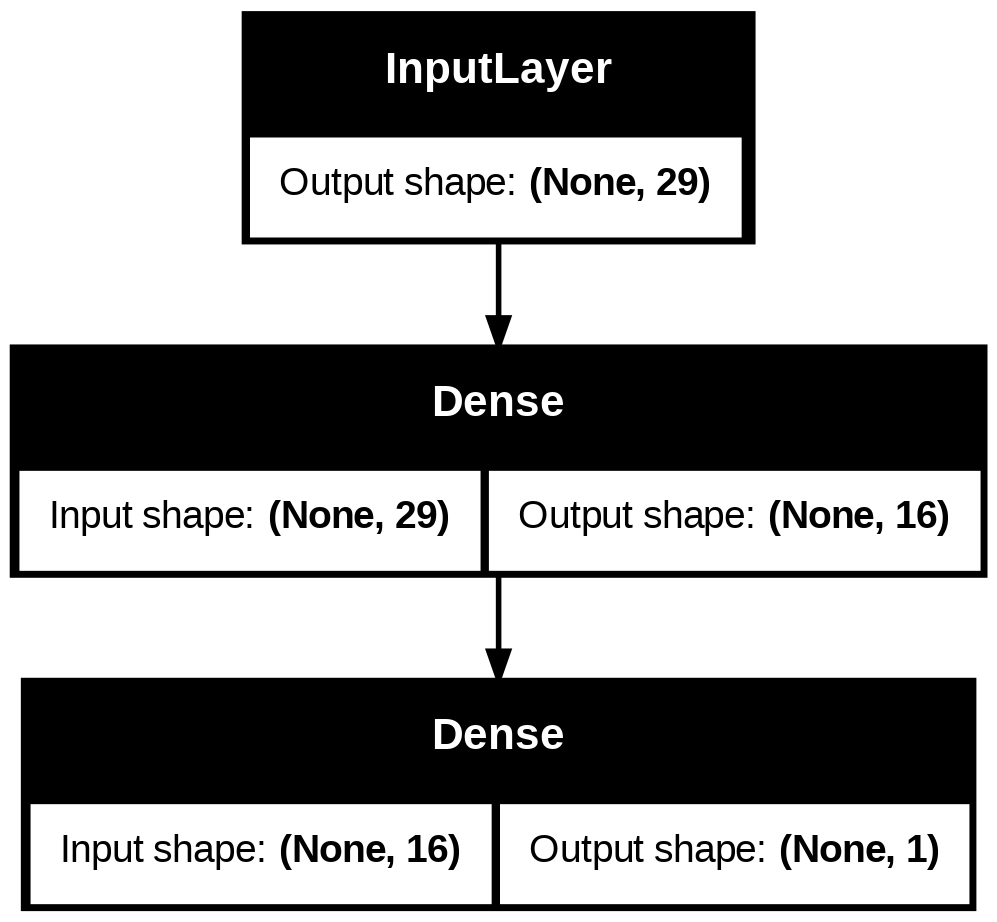

In [30]:
keras.utils.plot_model(model,show_shapes = True)

Now that the model is defined, we need to tell Keras three things:

*   What **loss function** to use - Since our output variable is binary, we will select the `binary_crossentropy` loss function.
*   Which **optimizer** to use - we will use a sibling of SGD called **Adam** which is an default choice
*   What **metrics** you want Keras to report out - in classification problems like this one, Accuracy is usually the metric you want to see.

These three choices can be made using the `model.fit` function.

In [31]:
from types import MethodDescriptorType
model.compile(optimizer="adam",
              loss = "binary_crossentropy",
              metrics = ["accuracy"])

# Train the model

In [ ]:
history = model.fit(train_X.astype(np.float32),
                    train_y.astype(np.float32),
                    epochs=100,
                    batch_size=32,
                    verbose=1,
                    validation_split=0.2)

Epoch 1/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 18ms/step - accuracy: 1.0000 - loss: 0.0136 - val_accuracy: 0.7551 - val_loss: 7.7868
Epoch 2/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0136 - val_accuracy: 0.7551 - val_loss: 7.7947
Epoch 3/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0135 - val_accuracy: 0.7551 - val_loss: 7.8018
Epoch 4/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0134 - val_accuracy: 0.7551 - val_loss: 7.8094
Epoch 5/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0133 - val_accuracy: 0.7551 - val_loss: 7.8174
Epoch 6/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0133 - val_accuracy: 0.7551 - val_loss: 7.8250
Epoch 7/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0132 - val_accuracy: 0.7551 - val_loss: 7.8324
Epoch 8/100
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 1.0000 - loss: 0.0131 - val_accuracy: 0.7551 - val_loss:

In [ ]:
history_dict = history.history
history_dict.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

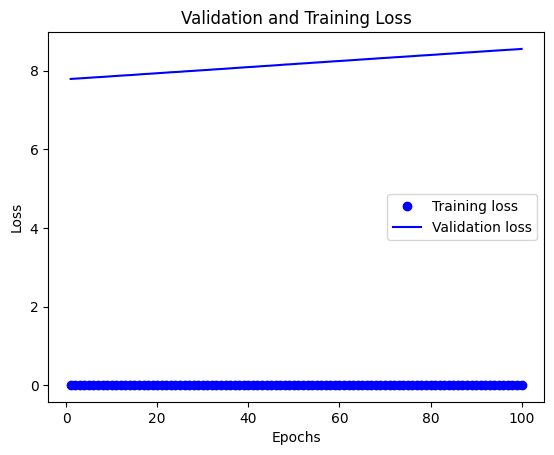

In [ ]:
loss_values = history_dict["loss"]
val_loss_values = history_dict["val_loss"]
epochs = range(1,len(loss_values) + 1)
plt.plot(epochs,loss_values,"bo",label="Training loss")
plt.plot(epochs,val_loss_values,"b",label="Validation loss")
plt.title("Validation and Training Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.show()

<module 'matplotlib.pyplot' from '/usr/local/lib/python3.12/dist-packages/matplotlib/pyplot.py'>

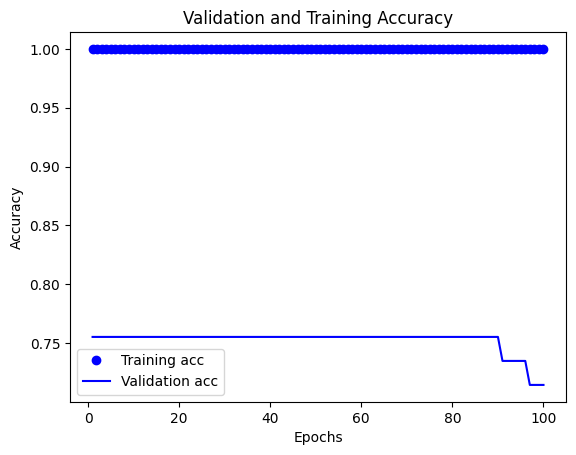

In [ ]:
plt.clf()
acc = history_dict["accuracy"]
val_acc = history_dict["val_accuracy"]
plt.plot(epochs,acc,"bo",label="Training acc")
plt.plot(epochs,val_acc,"b",label="Validation acc")
plt.title("Validation and Training Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt

In [ ]:
model.evaluate(test_X.astype(np.float32), test_y.astype(np.float32))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - accuracy: 0.8033 - loss: 0.9294


[0.9294074177742004, 0.8032786846160889]

Above represents "Validation loss increased while training loss decreased, indicating overfitting. I addressed this using scaling, dropout, and early stopping."

# Training the model - After overfitting

In [32]:
import tensorflow as tf
from tensorflow.keras import models, layers
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.layers import Normalization
import numpy as np

# -----------------------------
# Normalize Data
# -----------------------------

normalizer = Normalization()

normalizer.adapt(train_X)

# -----------------------------
# Build Model
# -----------------------------

model = models.Sequential([

    # Normalization Layer
    normalizer,

    # Hidden Layer 1
    layers.Dense(16, activation='relu'),

    # Dropout
    layers.Dropout(0.5),

    # Hidden Layer 2
    layers.Dense(16, activation='relu'),

    # Dropout
    layers.Dropout(0.5),

    # Output Layer
    layers.Dense(1, activation='sigmoid')

])

# -----------------------------
# Compile Model
# -----------------------------

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# -----------------------------
# Early Stopping
# -----------------------------

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

# -----------------------------
# Train Model
# -----------------------------

history = model.fit(
    train_X.astype(np.float32),
    train_y.astype(np.float32),
    epochs=300,
    batch_size=32,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# -----------------------------
# Evaluate
# -----------------------------

results = model.evaluate(
    test_X.astype(np.float32),
    test_y.astype(np.float32)
)

print(results)

Epoch 1/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 3s 82ms/step - accuracy: 0.5130 - loss: 0.7814 - val_accuracy: 0.5714 - val_loss: 0.7532
Epoch 2/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 34ms/step - accuracy: 0.5751 - loss: 0.7072 - val_accuracy: 0.5918 - val_loss: 0.7242
Epoch 3/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5803 - loss: 0.6583 - val_accuracy: 0.5714 - val_loss: 0.7000
Epoch 4/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 35ms/step - accuracy: 0.5596 - loss: 0.7289 - val_accuracy: 0.5510 - val_loss: 0.6795
Epoch 5/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 33ms/step - accuracy: 0.5648 - loss: 0.6787 - val_accuracy: 0.6327 - val_loss: 0.6621
Epoch 6/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6632 - loss: 0.6596 - val_accuracy: 0.6122 - val_loss: 0.6464
Epoch 7/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6166 - loss: 0.6395 - val_accuracy: 0.5714 - val_loss: 0.6322
Epoch 8/300
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6943 - loss: 0.5907 - val_accuracy: 0.6122 - val_loss:

In [33]:
history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

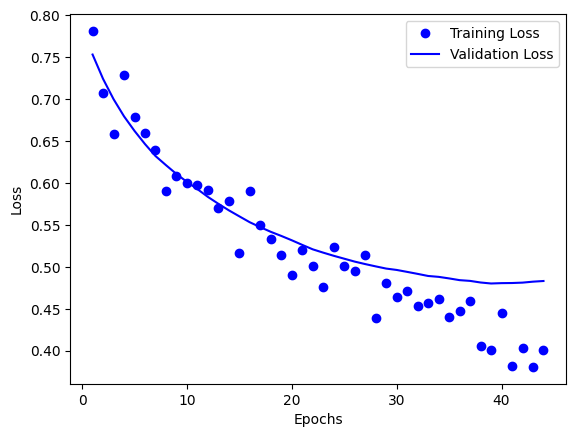

In [34]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()

plt.show()

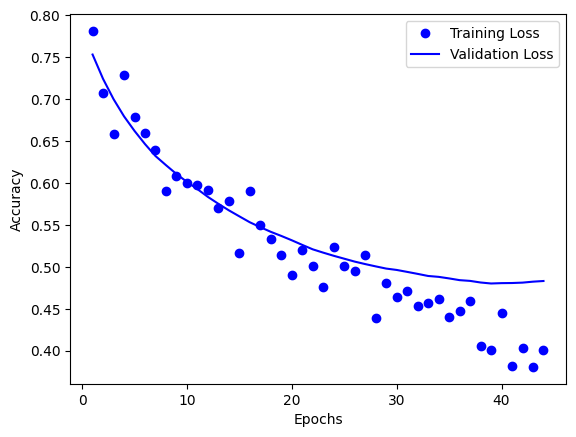

In [35]:
import matplotlib.pyplot as plt

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'bo', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')

plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()

plt.show()

# Evaluate the model

In [36]:
model.evaluate(test_X.astype(np.float32), test_y.astype(np.float32))

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - accuracy: 0.8033 - loss: 0.3946


[0.39456602931022644, 0.8032786846160889]

# Result

```
# Target
0	0.726073
1	0.273927
```
The binary classification model initially showed signs of overfitting, where validation loss increased despite improved training performance. By applying normalization, dropout, and early stopping, the model achieved more stable learning with improved generalization, reaching approximately 80% accuracy and reduced loss.

